# 12 · Parallelization — *extra pattern*

Two flavours (both run branches **at the same time**):

1. **Sectioning** – different sub-tasks in parallel, then merge (below, part A).
2. **Voting** – the *same* task several times, pick the majority (part B) → fewer mistakes from a small model.

(Unlike map-reduce, the branches here are a **fixed, known set**, not one-per-item.)

```
            +-> pros ---+
START ------+-> cons ---+--> combine -> END
            +-> cost ---+
```

In [1]:
# --- Model setup -------------------------------------------------------------
# 1) Ollama must be running   ->  `ollama serve`  (the desktop app does this for you)
# 2) Pull the models once     ->  `ollama pull llama3.1`  and  `ollama pull qwen3:0.6b`
from langchain_ollama import ChatOllama

# llama3.1 (8B): our main "brain" - good at tool calling & structured output.
llm = ChatOllama(model="llama3.1", temperature=0)

# qwen3:0.6b: a tiny, very fast model - great for cheap jobs (classify, summarise, route).
# reasoning=False hides qwen3's <think> block so `.content` is just the answer.
small_llm = ChatOllama(model="qwen3:0.6b", temperature=0, reasoning=False)

## A · Sectioning

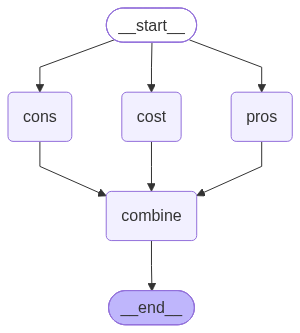

Here is a 4-line assessment:

**Pros:** A neighbourhood tool-lending library promotes community engagement, reduces individual tool ownership, and supports sustainability through tool reuse.  
**Cons:** It poses risks of theft and vandalism.  
**Cost:** Establishment and maintenance require a modest effort and cost.


In [2]:
import operator
from collections import Counter
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    idea: str
    parts: Annotated[list[str], operator.add]     # every branch appends here
    report: str

def make_branch(label: str, instruction: str):
    def branch(state: State):
        text = small_llm.invoke(f"{instruction}\nIdea: {state['idea']}\nMax 2 sentences.").content
        return {"parts": [f"{label}: {text}"]}
    return branch

def combine(state: State):
    joined = "\n".join(state["parts"])
    return {"report": llm.invoke(f"Merge into a tidy 4-line assessment:\n{joined}").content}

builder = StateGraph(State)
builder.add_node("pros", make_branch("PROS", "List the main benefits."))
builder.add_node("cons", make_branch("CONS", "List the main risks."))
builder.add_node("cost", make_branch("COST", "Estimate rough cost and effort."))
builder.add_node("combine", combine)

for n in ("pros", "cons", "cost"):
    builder.add_edge(START, n)          # 3 edges out of START => all three run in parallel
    builder.add_edge(n, "combine")      # combine waits until ALL incoming branches are done
builder.add_edge("combine", END)
graph = builder.compile()

from IPython.display import display, Image

# Visualize the agent's decision-making flow
display(Image(graph.get_graph().draw_mermaid_png()))

print(graph.invoke({"idea": "A neighbourhood tool-lending library", "parts": []})["report"])

## B · Voting (self-consistency)
Ask the tiny model the same yes/no question 5 times in parallel; trust the majority.

In [3]:
from concurrent.futures import ThreadPoolExecutor

def vote(question: str, n: int = 5) -> str:
    def ask(_):
        return small_llm.invoke(f"{question}\nAnswer only YES or NO.").content.strip().upper()[:3].strip(".")
    with ThreadPoolExecutor(n) as pool:                # plain threads are enough for I/O-bound LLM calls
        answers = list(pool.map(ask, range(n)))
    winner, count = Counter(answers).most_common(1)[0]
    print(f"votes={answers} -> {winner} ({count}/{n})")
    return winner

vote("Is 97 a prime number?")

votes=['YES', 'YES', 'YES', 'YES', 'YES'] -> YES (5/5)


'YES'